In [1]:
import pandas as pd

df = pd.read_csv("online_shoppers_intention.csv")

df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [2]:
df = df.dropna()

In [3]:
df['BounceRates'].fillna(df['BounceRates'].mean(), inplace=True)

In [4]:
df['Month'].fillna(df['Month'].mode()[0], inplace=True)

In [5]:
df['PageValues'].fillna(df['PageValues'].median(), inplace=True)

In [6]:
df.info()
df.describe()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [7]:
df.duplicated().sum()
df = df.drop_duplicates()

In [8]:
df['Month'] = df['Month'].astype('category').cat.codes
df['VisitorType'] = df['VisitorType'].astype('category').cat.codes
df['Weekend'] = df['Weekend'].astype(int)
df['Revenue'] = df['Revenue'].astype(int)

In [9]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
count,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000
mean,2.338878,81.646331,0.508726,34.825454,32.045637,1206.982457,0.020370,0.041466,5.949574,0.061942,5.168046,2.124211,2.357804,3.153298,4.073904,1.715936,0.234248,0.156329
std,3.330436,177.491845,1.275617,141.424807,44.593649,1919.601400,0.045255,0.046163,18.653671,0.199666,2.374071,0.906823,1.710114,2.402340,4.016654,0.693425,0.423545,0.363182
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,8.000000,193.000000,0.000000,0.014231,0.000000,0.000000,5.000000,2.000000,2.000000,1.000000,2.000000,2.000000,0.000000,0.000000
50%,1.000000,9.000000,0.000000,0.000000,18.000000,608.942857,0.002899,0.025000,0.000000,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,2.000000,0.000000,0.000000
75%,4.000000,94.700000,0.000000,0.000000,38.000000,1477.154762,0.016667,0.048529,0.000000,0.000000,7.000000,3.000000,2.000000,4.000000,4.000000,2.000000,0.000000,0.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,9.000000,8.000000,13.000000,9.000000,20.000000,2.000000,1.000000,1.000000


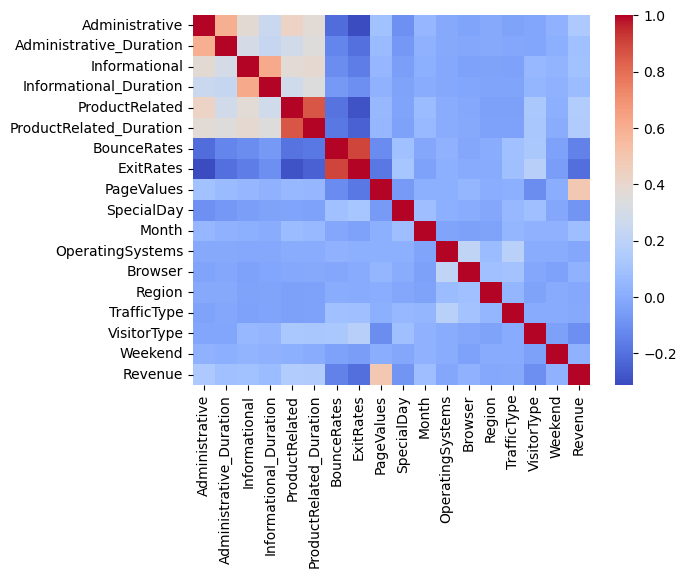

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()

<Axes: >

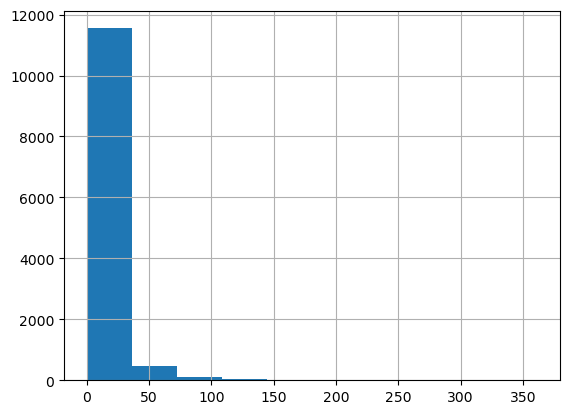

In [11]:
df['PageValues'].hist()

<Axes: xlabel='Revenue', ylabel='count'>

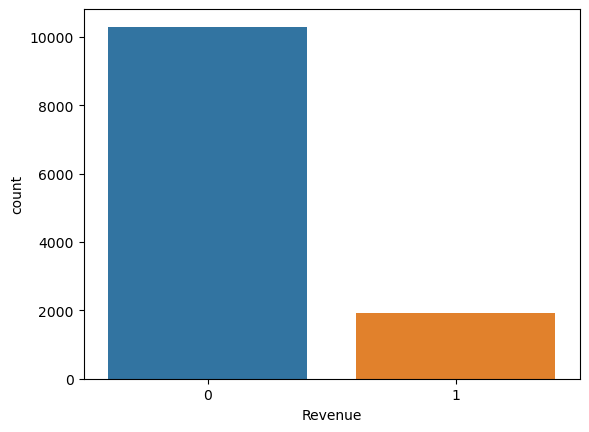

In [12]:
sns.countplot(x='Revenue', data=df)

<Axes: xlabel='Revenue', ylabel='PageValues'>

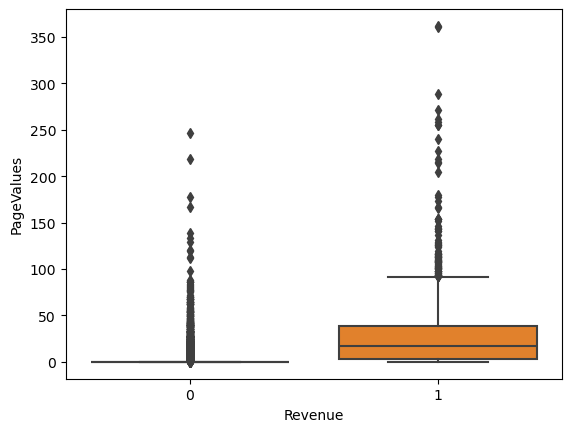

In [13]:
sns.boxplot(x='Revenue', y='PageValues', data=df)

In [14]:
X = df.drop('Revenue', axis=1)
y = df['Revenue']

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [17]:
from sklearn.metrics import accuracy_score, confusion_matrix

y_pred = model.predict(X_test)


confusion_matrix(y_test, y_pred)

array([[2016,   63],
       [ 161,  201]], dtype=int64)

In [18]:
accuracy_score(y_test, y_pred)

0.9082343301925441

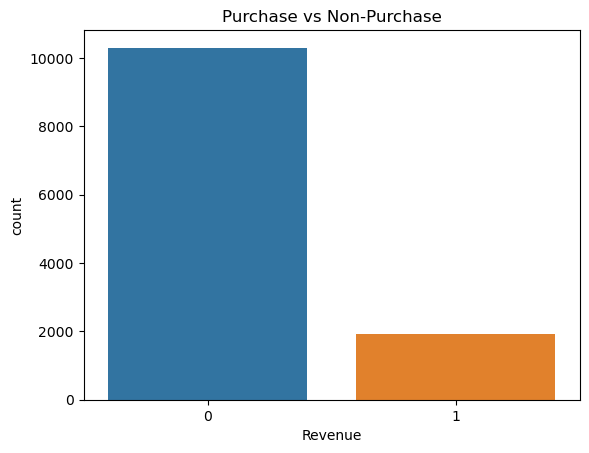

In [19]:
sns.countplot(x='Revenue', data=df)
plt.title("Purchase vs Non-Purchase")
plt.show()

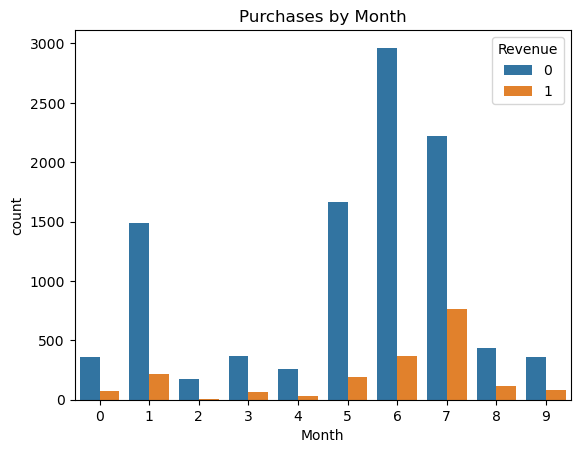

In [20]:
df['Revenue'] = df['Revenue'].astype(str)

sns.countplot(x='Month', hue='Revenue', data=df)
plt.title("Purchases by Month")
plt.show()

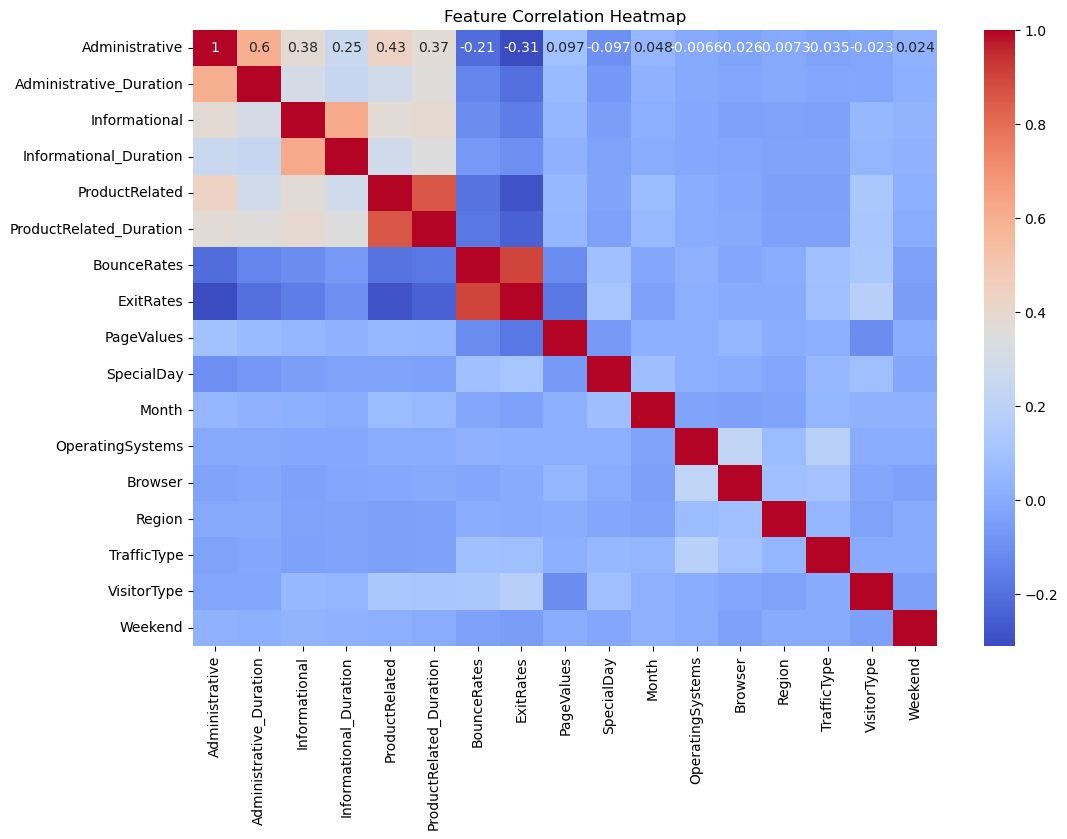

In [21]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

In [22]:
df['Revenue'].value_counts()

Revenue
0    10297
1     1908
Name: count, dtype: int64

In [23]:
import pandas as pd

pd.crosstab(df['VisitorType'], df['Revenue'], normalize='index')

Revenue,0,1
VisitorType,,
0,0.750738,0.249262
1,0.802469,0.197531
2,0.859074,0.140926


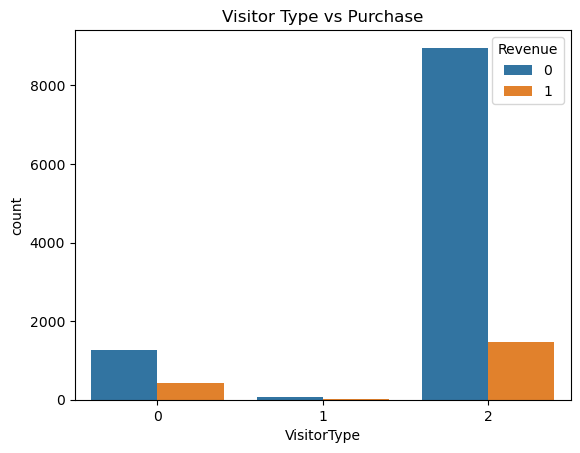

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='VisitorType', hue='Revenue', data=df)
plt.title("Visitor Type vs Purchase")
plt.show()

In [25]:
df.groupby('Revenue')['PageValues'].mean()

Revenue
0     1.999985
1    27.264518
Name: PageValues, dtype: float64

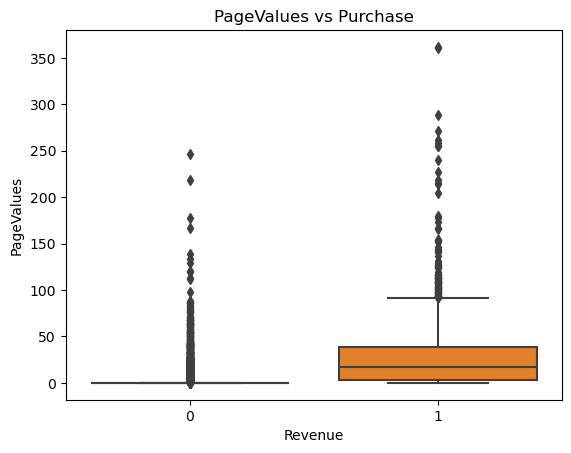

In [26]:
sns.boxplot(x='Revenue', y='PageValues', data=df)
plt.title("PageValues vs Purchase")
plt.show()

In [27]:
df.groupby('Revenue')['BounceRates'].mean()

Revenue
0    0.023197
1    0.005117
Name: BounceRates, dtype: float64

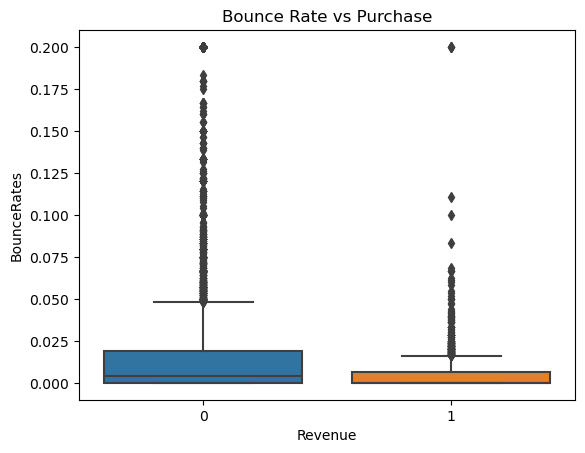

In [28]:
sns.boxplot(x='Revenue', y='BounceRates', data=df)
plt.title("Bounce Rate vs Purchase")
plt.show()

In [29]:
df.groupby('Revenue')['ProductRelated'].mean()

Revenue
0    29.050403
1    48.210168
Name: ProductRelated, dtype: float64

In [30]:
pd.crosstab(df['Month'], df['Revenue'], normalize='index')

Revenue,0,1
Month,,
0,0.824480,0.175520
1,0.873388,0.126612
2,0.983425,0.016575
3,0.847222,0.152778
4,0.898246,0.101754
5,0.896774,0.103226
6,0.890357,0.109643
7,0.745137,0.254863
8,0.790528,0.209472


In [31]:
pd.crosstab(df['Weekend'], df['Revenue'], normalize='index')

Revenue,0,1
Weekend,,
0,0.849240,0.150760
1,0.825463,0.174537


In [32]:
from scipy.stats import ttest_ind

group1 = df[df['Revenue']==1]['PageValues']
group2 = df[df['Revenue']==0]['PageValues']

ttest_ind(group1, group2)

TtestResult(statistic=nan, pvalue=nan, df=nan)

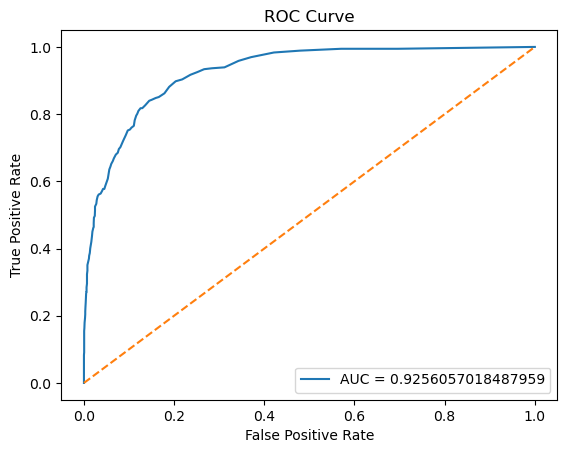

In [34]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = " + str(roc_auc))
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [36]:
lr = LogisticRegression(max_iter=1000)
dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)

lr.fit(X_train, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)

C:\Users\Tejashvini\anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


RandomForestClassifier(random_state=42)

In [37]:
y_pred_lr = lr.predict(X_test)
y_pred_dt = dt.predict(X_test)
y_pred_rf = rf.predict(X_test)

In [38]:
from sklearn.metrics import accuracy_score

print("Logistic Regression:", accuracy_score(y_test, y_pred_lr))
print("Decision Tree:", accuracy_score(y_test, y_pred_dt))
print("Random Forest:", accuracy_score(y_test, y_pred_rf))

Logistic Regression: 0.8869315854158132
Decision Tree: 0.8578451454321999
Random Forest: 0.9041376485047112


In [39]:
from sklearn.metrics import classification_report

print("Logistic Regression\n", classification_report(y_test, y_pred_lr))
print("Decision Tree\n", classification_report(y_test, y_pred_dt))
print("Random Forest\n", classification_report(y_test, y_pred_rf))

Logistic Regression
               precision    recall  f1-score   support

           0       0.90      0.98      0.94      2079
           1       0.74      0.36      0.49       362

    accuracy                           0.89      2441
   macro avg       0.82      0.67      0.71      2441
weighted avg       0.88      0.89      0.87      2441

Decision Tree
               precision    recall  f1-score   support

           0       0.92      0.91      0.92      2079
           1       0.52      0.56      0.54       362

    accuracy                           0.86      2441
   macro avg       0.72      0.73      0.73      2441
weighted avg       0.86      0.86      0.86      2441

Random Forest
               precision    recall  f1-score   support

           0       0.92      0.97      0.94      2079
           1       0.74      0.54      0.63       362

    accuracy                           0.90      2441
   macro avg       0.83      0.76      0.79      2441
weighted avg       0.90

In [40]:
from sklearn.metrics import confusion_matrix

print("LR Confusion Matrix\n", confusion_matrix(y_test, y_pred_lr))
print("DT Confusion Matrix\n", confusion_matrix(y_test, y_pred_dt))
print("RF Confusion Matrix\n", confusion_matrix(y_test, y_pred_rf))

LR Confusion Matrix
 [[2034   45]
 [ 231  131]]
DT Confusion Matrix
 [[1893  186]
 [ 161  201]]
RF Confusion Matrix
 [[2010   69]
 [ 165  197]]


In [41]:
import pandas as pd

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ]
})

print(results)

                 Model  Accuracy
0  Logistic Regression  0.886932
1        Decision Tree  0.857845
2        Random Forest  0.904138


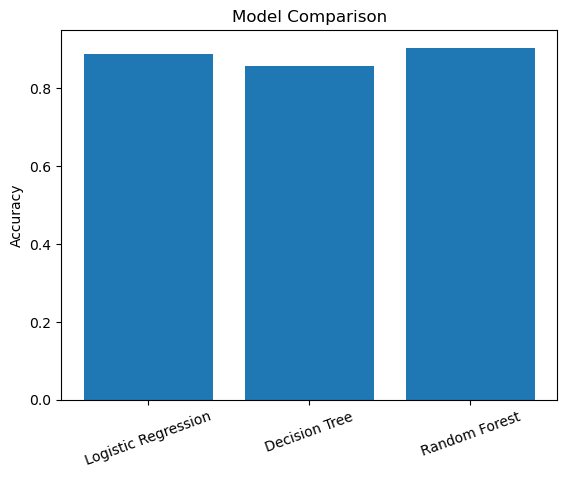

In [42]:
import matplotlib.pyplot as plt

plt.bar(results['Model'], results['Accuracy'])
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.show()